# EEG_12 — W-HGNN Subject-Specific LOSO

Windowed HGNN in modalità subject-specific (Leave-One-Session-Out).

- **Modello**: W-HGNN (da EEG_11) — H_pruned soft fisso, feature nodo per finestra
- **Split**: test=ultima sessione, val=penultima, train=resto (LOSO per sessione)
- **Metrica**: abs_pcc pruned (migliore da EEG_07f; ablation EEG_11 mostra metriche equivalenti)
- **Output**: ranking soggetti per test bAcc (top-1 + top-2)

Confronto atteso con EEG_09b (HGNN statico):
EEG_09b best: P031=0.318, P015~0.53 (top-2). W-HGNN dovrebbe catturare pattern temporali locali.

In [1]:
import json, logging, re, traceback
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import balanced_accuracy_score, recall_score
from tqdm.auto import tqdm
import wandb

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)-8s %(message)s', datefmt='%H:%M:%S')
log = logging.getLogger('eeg12')

project_root = next((p for p in [Path.cwd()]+list(Path.cwd().parents) if (p/'.git').exists()), Path.cwd())
FIG_DIR  = project_root / 'figures'; FIG_DIR.mkdir(exist_ok=True)
CKPT_DIR = project_root / 'models' / 'eeg12'; CKPT_DIR.mkdir(parents=True, exist_ok=True)

# ---- CONFIG ----
N_CHANNELS = 61
N_SAMPLES  = 384
METRIC     = 'abs_pcc'
N_CLASSES  = 4
CLUSTER_SCHEME = 'concr4'

# W-HGNN iperparametri
K_WINDOWS  = 8
D_NODE     = 16
HIDDEN     = 64
N_LAYERS   = 1
DROPOUT    = 0.6

# Training
LR               = 1e-3
WEIGHT_DECAY     = 5e-3
GRAD_CLIP        = 1.0
BATCH_SIZE       = 32
MAX_EPOCHS       = 80
PATIENCE         = 7
USE_INSTANCE_NORM = True
LABEL_SMOOTHING  = 0.2
MIXUP_ALPHA      = 0.4   # Beta(α,α); 0.0 = disabilitato

# ── Data Augmentation (solo training) ─────────────────────────────────────────
USE_AUGMENTATION = True
AUG_NOISE_STD    = 0.05
AUG_AMP_RANGE    = (0.85, 1.15)
AUG_SHIFT_MAX    = 15
AUG_MASK_LEN     = 20

WANDB_ENTITY  = 'uras-daniele22-politecnico-di-milano'
WANDB_PROJECT = 'miralis-imagined-speech'

T_WIN = N_SAMPLES // K_WINDOWS

_PAT  = re.compile(r'^P(\d+)_S(\d+)$')
label2cluster = {int(k): int(v) for k,v in json.loads(
    (project_root/'configs'/'label_schemes'/'labelid2cluster_concr4.json').read_text()).items()}

HG_ROOT = project_root / 'data' / f'hypergraphs_pruned_{METRIC}'

subj_sess = defaultdict(lambda: defaultdict(list))
for p in sorted(HG_ROOT.rglob('trial_*.pt')):
    m = _PAT.match(p.parent.name)
    if m:
        subj_sess[int(m.group(1))][int(m.group(2))].append(p)

ALL_SUBJ = sorted(subj_sess.keys())
log.info(f'HG_ROOT: {HG_ROOT}')
log.info(f'Soggetti: {len(ALL_SUBJ)}  T_WIN={T_WIN}  K={K_WINDOWS}  D_NODE={D_NODE}')
log.info(f'Overfitting fixes: dropout={DROPOUT}  wd={WEIGHT_DECAY}  mixup={MIXUP_ALPHA}  '
         f'label_smooth={LABEL_SMOOTHING}  patience={PATIENCE}')

/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
12:08:44 INFO     HG_ROOT: /home/daniele_u/miralis-hypergraph-imagined-speech/data/hypergraphs_pruned_abs_pcc
12:08:44 INFO     Soggetti: 74  T_WIN=48  K=8  D_NODE=16
12:08:44 INFO     Overfitting fixes: dropout=0.6  wd=0.005  mixup=0.4  label_smooth=0.2  patience=7


## §2 — Dataset LOSO (H_pruned soft)

In [2]:
def _augment_eeg(x):
    """
    x: (61, T) tensor già normalizzato con instance norm.
    Applica augmentazioni EEG standard — solo su training set.
    Ogni trasformazione attivata con p=0.5 indipendentemente.
    """
    x = x.clone()
    # 1. Gaussian noise (σ=0.05 × std unitario post-norm)
    if torch.rand(1) < 0.5:
        x = x + torch.randn_like(x) * AUG_NOISE_STD
    # 2. Amplitude scaling
    if torch.rand(1) < 0.5:
        x = x * torch.empty(1).uniform_(*AUG_AMP_RANGE)
    # 3. Temporal shift circolare
    if torch.rand(1) < 0.5:
        shift = torch.randint(-AUG_SHIFT_MAX, AUG_SHIFT_MAX + 1, (1,)).item()
        x = torch.roll(x, shift, dims=1)
    # 4. Temporal masking (zeroing di un blocco casuale)
    if torch.rand(1) < 0.3:
        T = x.shape[1]
        start = torch.randint(0, T - AUG_MASK_LEN, (1,)).item()
        x[:, start:start + AUG_MASK_LEN] = 0.0
    # 5. Channel dropout (azzera 1 canale casuale)
    if torch.rand(1) < 0.2:
        ch = torch.randint(0, x.shape[0], (1,)).item()
        x[ch] = 0.0
    return x


class HGWindowDatasetSS(Dataset):
    """
    Carica x (61,384), H_pruned soft (61,61) e y.
    augment=True: applica _augment_eeg solo durante training.
    """
    def __init__(self, paths_and_labels, use_instance_norm=True, augment=False):
        self.items = paths_and_labels
        self.use_instance_norm = use_instance_norm
        self.augment = augment

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        p, label = self.items[idx]
        d = torch.load(p, weights_only=False)
        x = d['x'].float()   # (61, 384)
        H = d['H'].float()   # (61, E)

        if self.use_instance_norm:
            x = (x - x.mean(dim=1, keepdim=True)) / (x.std(dim=1, keepdim=True) + 1e-6)

        if self.augment:
            x = _augment_eeg(x)

        # Pad/tronca H a (N_CHANNELS, N_CHANNELS)
        if H.shape[1] < N_CHANNELS:
            H = F.pad(H, (0, N_CHANNELS - H.shape[1]))
        elif H.shape[1] > N_CHANNELS:
            H = H[:, :N_CHANNELS]

        return x, H, torch.tensor(label, dtype=torch.long)


def _collect(subj_id, sess_list):
    items = []
    for s in sess_list:
        for p in subj_sess[subj_id][s]:
            d = torch.load(p, weights_only=False)
            y_word = int(d['y'].squeeze()) if isinstance(d['y'], torch.Tensor) else int(d['y'])
            c = label2cluster.get(y_word)
            if c is not None:
                items.append((p, c))
    return items


def make_loso_loaders(subj_id):
    """LOSO: test=ultima sessione, val=penultima, train=resto."""
    sids = sorted(subj_sess[subj_id].keys())
    if len(sids) < 2:
        return None
    test_sess  = sids[-1]
    val_sess   = sids[-2]
    train_sess = [s for s in sids if s not in (test_sess, val_sess)]

    tr_items = _collect(subj_id, train_sess)
    va_items = _collect(subj_id, [val_sess])
    te_items = _collect(subj_id, [test_sess])
    if not tr_items or not te_items:
        return None

    tr_labels = np.array([it[1] for it in tr_items])
    counts    = np.bincount(tr_labels, minlength=N_CLASSES)
    sample_w  = torch.tensor(1.0 / counts[tr_labels], dtype=torch.float)
    sampler   = WeightedRandomSampler(sample_w, len(sample_w), replacement=True)

    kw = dict(num_workers=0, pin_memory=False)
    return (
        DataLoader(HGWindowDatasetSS(tr_items, USE_INSTANCE_NORM, augment=USE_AUGMENTATION),
                   BATCH_SIZE, sampler=sampler, **kw),
        DataLoader(HGWindowDatasetSS(va_items, USE_INSTANCE_NORM, augment=False),
                   BATCH_SIZE, shuffle=False, **kw),
        DataLoader(HGWindowDatasetSS(te_items, USE_INSTANCE_NORM, augment=False),
                   BATCH_SIZE, shuffle=False, **kw),
    )


## §3 — Modello: W-HGNN

In [3]:
class HGNNConv(nn.Module):
    """HGNN layer (Feng et al. 2019) — batched bmm."""
    def __init__(self, in_ch, out_ch, bias=True):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(in_ch, out_ch))
        self.bias   = nn.Parameter(torch.zeros(out_ch)) if bias else None
        nn.init.xavier_uniform_(self.weight)

    def forward(self, X, H):
        # X: (B,N,C)  H: (B,N,E) soft
        d_v = H.sum(dim=2).clamp(min=1e-6)
        d_e = H.sum(dim=1).clamp(min=1e-6)
        Dv  = (1.0 / d_v.sqrt()).unsqueeze(-1)
        De  = (1.0 / d_e).unsqueeze(1)
        out = Dv * (X @ self.weight)
        out = torch.bmm(H.transpose(1, 2), out)
        out = De.transpose(1, 2) * out
        out = torch.bmm(H, out)
        out = Dv * out
        if self.bias is not None: out = out + self.bias
        return out


class WindowedHGNN(nn.Module):
    """
    W-HGNN: H_pruned soft FISSA per tutte le finestre.
    I feature dei nodi (Linear 48->d_node) variano per finestra k.
    z = mean(HGNN(feat_k, H)) over k -> clf.
    """
    def __init__(self, T_win=T_WIN, K=K_WINDOWS, d_node=D_NODE,
                 hidden=HIDDEN, n_classes=N_CLASSES, n_layers=N_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.K, self.T_win = K, T_win
        self.node_proj = nn.Sequential(
            nn.Linear(T_win, d_node),
            nn.LayerNorm(d_node),
            nn.ELU(),
        )
        dims = [d_node] + [hidden] * n_layers
        self.convs = nn.ModuleList([HGNNConv(dims[i], dims[i+1]) for i in range(n_layers)])
        self.bns   = nn.ModuleList([nn.BatchNorm1d(hidden) for _ in range(n_layers)])
        self.drop  = nn.Dropout(dropout)
        self.clf   = nn.Linear(hidden, n_classes)

    def forward(self, x, H):
        # x: (B,N,T)  H: (B,N,N) soft — stessa per tutte le finestre
        B, N, T = x.shape
        outs = []
        for k in range(self.K):
            x_k  = x[:, :, k*self.T_win:(k+1)*self.T_win]   # (B,N,T_win) — varia
            feat = self.node_proj(x_k)                        # (B,N,d_node) — varia
            out  = feat
            for conv, bn in zip(self.convs, self.bns):
                out = conv(out, H)                            # H fisso
                out = bn(out.reshape(B*N, -1)).reshape(B, N, -1)
                out = F.relu(out)
                out = self.drop(out)
            outs.append(out.mean(dim=1))                      # (B,hidden)
        return self.clf(torch.stack(outs, dim=1).mean(dim=1))


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
log.info(f'device: {device}')
_m = WindowedHGNN()
n_p = sum(p.numel() for p in _m.parameters() if p.requires_grad)
log.info(f'WindowedHGNN — {n_p:,} parametri  K={K_WINDOWS} x {T_WIN}sample')
del _m


12:08:44 INFO     device: cuda
12:08:44 INFO     WindowedHGNN — 2,292 parametri  K=8 x 48sample


## §4 — Train / Eval

In [4]:
_criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)


def _mixup(x, y, alpha=MIXUP_ALPHA):
    lam = float(np.random.beta(alpha, alpha)) if alpha > 0 else 1.0
    idx = torch.randperm(len(x), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam


def run_epoch(model, loader, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()
    total_loss, all_labels, all_preds = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, H, y in loader:
            x, H, y = x.to(device), H.to(device), y.to(device)
            if train and MIXUP_ALPHA > 0:
                x, y_a, y_b, lam = _mixup(x, y)
                logits = model(x, H)
                loss = lam * _criterion(logits, y_a) + (1 - lam) * _criterion(logits, y_b)
            else:
                logits = model(x, H)
                loss   = _criterion(logits, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()
            total_loss += loss.item() * len(y)
            all_labels.extend(y.cpu().numpy())
            all_preds.extend(logits.argmax(1).cpu().numpy())
    bacc = balanced_accuracy_score(all_labels, all_preds)
    return total_loss / len(loader.dataset), bacc, np.array(all_labels), np.array(all_preds)


def train_subject(subj_id, tr_l, va_l, te_l):
    run_name = f'eeg12_WHGNN_P{subj_id:03d}_{CLUSTER_SCHEME}'
    cfg = dict(
        notebook='EEG_12', model='WindowedHGNN_SS', subject=f'P{subj_id:03d}',
        metric=METRIC, n_classes=N_CLASSES,
        k_windows=K_WINDOWS, t_win=T_WIN, d_node=D_NODE,
        hidden=HIDDEN, n_layers=N_LAYERS, dropout=DROPOUT,
        lr=LR, weight_decay=WEIGHT_DECAY, grad_clip=GRAD_CLIP,
        batch_size=BATCH_SIZE, max_epochs=MAX_EPOCHS,
        use_instance_norm=USE_INSTANCE_NORM,
        label_smoothing=LABEL_SMOOTHING,
        mixup_alpha=MIXUP_ALPHA,
        weighted_sampler=True,
        use_augmentation=USE_AUGMENTATION,
        aug_noise_std=AUG_NOISE_STD,
        aug_amp_range=AUG_AMP_RANGE,
        aug_shift_max=AUG_SHIFT_MAX,
        topology='H_pruned_soft_fixed',
    )
    run = wandb.init(entity=WANDB_ENTITY, project=WANDB_PROJECT,
                     name=run_name, config=cfg, reinit='finish_previous',
                     settings=wandb.Settings(start_method='thread'))

    model = WindowedHGNN().to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=MAX_EPOCHS)
    best_val, best_state, patience_cnt = 0.0, None, 0

    for epoch in range(1, MAX_EPOCHS + 1):
        tr_loss, tr_b, _, _ = run_epoch(model, tr_l, opt)
        va_loss, va_b, _, _ = run_epoch(model, va_l)
        sched.step()
        run.log({'train/loss': tr_loss, 'train/bacc': tr_b,
                 'val/loss': va_loss,   'val/bacc': va_b,
                 'train_val_gap': tr_b - va_b, 'epoch': epoch})
        if va_b > best_val:
            best_val = va_b
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
        if patience_cnt >= PATIENCE:
            log.info(f'  P{subj_id:03d} early stop @ epoch {epoch}')
            break

    model.load_state_dict(best_state)
    _, te_b, te_lbl, te_pred = run_epoch(model, te_l)

    ckpt = CKPT_DIR / f'P{subj_id:03d}.pt'
    torch.save({'state_dict': best_state, 'val_bacc': best_val, 'test_bacc': te_b,
                'labels': te_lbl, 'preds': te_pred}, ckpt)

    run.summary['val_bacc']  = best_val
    run.summary['test_bacc'] = te_b
    run.log({'confusion_matrix': wandb.plot.confusion_matrix(
        preds=te_pred.tolist(), y_true=te_lbl.tolist(),
        class_names=['CONCR', 'AZIONE', 'STATO', 'ASTRATTO'])})
    run.finish()
    return {'val_bacc': best_val, 'test_bacc': te_b, 'labels': te_lbl, 'preds': te_pred}


## §5 — Loop su Tutti i Soggetti

In [5]:
SUBJECT_RESULTS = {}

for sid in tqdm(ALL_SUBJ, desc='Soggetti'):
    loaders = make_loso_loaders(sid)
    if loaders is None:
        log.warning(f'P{sid:03d}: skip (dati insufficienti)')
        continue
    tr_l, va_l, te_l = loaders
    log.info(f'P{sid:03d}: train={len(tr_l.dataset)} val={len(va_l.dataset)} test={len(te_l.dataset)}')
    try:
        SUBJECT_RESULTS[sid] = train_subject(sid, tr_l, va_l, te_l)
        log.info(f'  P{sid:03d}: val={SUBJECT_RESULTS[sid]["val_bacc"]:.4f} '
                 f'test={SUBJECT_RESULTS[sid]["test_bacc"]:.4f}')
    except Exception as e:
        log.error(f'P{sid:03d}: {e}\n{traceback.format_exc()}')


Soggetti:   0%|          | 0/74 [00:00<?, ?it/s]

12:08:45 INFO     P000: train=330 val=110 test=110
wandb: WARNING `start_method` is deprecated and will be removed in a future version of wandb. This setting is currently non-functional and safely ignored.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/daniele_u/.netrc.
wandb: Currently logged in as: uras-daniele22 (uras-daniele22-politecnico-di-milano) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


12:08:52 INFO       P000 early stop @ epoch 13


epoch,▁▂▂▃▃▄▅▅▆▆▇▇█
train/bacc,▂▃▂▃▇▁▅▁▃▄▂▃█
train/loss,█▃▃▃▃▅▂▄▃▁▄▂▂
train_val_gap,▅▄▂▆▇▁▆▁▆█▇▃▆
val/bacc,▄▆█▄▅█▅▇▄▂▁▇█
val/loss,▄▁▃▅█▆▅▅▅▆▇▅▅
epoch,13
test_bacc,0.27315
train/bacc,0.2923
train/loss,1.38315
train_val_gap,0.0251


12:08:55 INFO       P000: val=0.2685 test=0.2731
12:08:55 INFO     P001: train=330 val=110 test=110


...

epoch,▁▂▂▃▃▄▄▅▅▆▆▇▇█
train/bacc,▄▄▁▁▃▆▅▄▇▆▇▄█▅
train/loss,▅▁█▃▄▃▃▂▂▃▂▁▂▄
train_val_gap,█▅▂▃▄▂▁▄▅▄▃▃▇▄
val/bacc,▁▄▆▅▄▇█▄▅▅▇▅▄▅
val/loss,▅▇▄▅▇█▄▂▁▂▅▃▃▆
epoch,14
test_bacc,0.22403
train/bacc,0.25336
train/loss,1.38873
train_val_gap,-0.00999


12:20:57 INFO       P071: val=0.3114 test=0.2240
12:20:58 INFO     P072: train=330 val=110 test=110


12:21:02 INFO       P072 early stop @ epoch 9


epoch,▁▂▃▄▅▅▆▇█
train/bacc,▁▂▃▃▂█▆▂▂
train/loss,█▅▃▃▄▂▂▁▃
train_val_gap,▃▁▇▄▇█▅▃█
val/bacc,▆█▃▆▂▃▆▆▁
val/loss,█▃▃▃▃▂▁▁▂
epoch,9
test_bacc,0.23701
train/bacc,0.25124
train/loss,1.38793
train_val_gap,0.05721


12:21:06 INFO       P072: val=0.2727 test=0.2370
12:21:06 WARNING  P073: skip (dati insufficienti)


## §6 — Ricarica da Checkpoint + Ranking

In [6]:
if not SUBJECT_RESULTS:
    log.info('Ricarico da checkpoint...')
    for ckpt in sorted(CKPT_DIR.glob('P*.pt')):
        sid = int(ckpt.stem[1:])
        d = torch.load(ckpt, weights_only=False)
        SUBJECT_RESULTS[sid] = {k: d[k] for k in ('val_bacc', 'test_bacc', 'labels', 'preds')}
    log.info(f'Ricaricati {len(SUBJECT_RESULTS)} soggetti')

if not SUBJECT_RESULTS:
    print('[INFO] Nessun risultato — esegui prima §5.')
else:
    def top2_bacc(labels, preds, n_classes=N_CLASSES):
        recalls = recall_score(labels, preds, average=None, zero_division=0,
                               labels=list(range(n_classes)))
        top2_cls = np.argsort(recalls)[-2:]
        mask = np.isin(labels, top2_cls)
        if mask.sum() == 0: return np.nan, top2_cls.tolist()
        return balanced_accuracy_score(labels[mask], preds[mask]), top2_cls.tolist()

    rows = []
    for sid, res in SUBJECT_RESULTS.items():
        lbl = np.array(res['labels']); pred = np.array(res['preds'])
        t2, top2_cls = top2_bacc(lbl, pred)
        rows.append({'Subject': f'P{sid:03d}',
                     'Test bAcc': round(res['test_bacc'], 4),
                     'Top2 bAcc': round(t2, 4) if not np.isnan(t2) else np.nan})

    df_top1 = pd.DataFrame(rows).sort_values('Test bAcc', ascending=False).reset_index(drop=True)
    df_top2 = pd.DataFrame(rows).sort_values('Top2 bAcc', ascending=False).reset_index(drop=True)
    df_top1.to_csv(FIG_DIR / 'eeg12_subject_ranking.csv', index=False)
    print('Top-10 by Test bAcc:')
    print(df_top1.head(10).to_string(index=False))
    print(f'\nMediana: {df_top1["Test bAcc"].median():.4f}  '
          f'Mean: {df_top1["Test bAcc"].mean():.4f}  '
          f'Max: {df_top1["Test bAcc"].max():.4f}')

    # confronto con EEG_09b
    EEG09B = {
        'P031': 0.318, 'P015': None,  # top soggetti EEG_09b
    }


Top-10 by Test bAcc:
Subject  Test bAcc  Top2 bAcc
   P018     0.4394     0.8333
   P023     0.3347     0.5027
   P028     0.3075     0.5873
   P059     0.2975     0.4760
   P002     0.2973     0.5833
   P041     0.2966     0.5655
   P036     0.2955     0.5000
   P070     0.2901     0.3611
   P053     0.2895     0.5274
   P008     0.2871     0.5492

Mediana: 0.2500  Mean: 0.2533  Max: 0.4394


/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924

## §7 — Bar Chart Ranking + Confronto EEG_09b

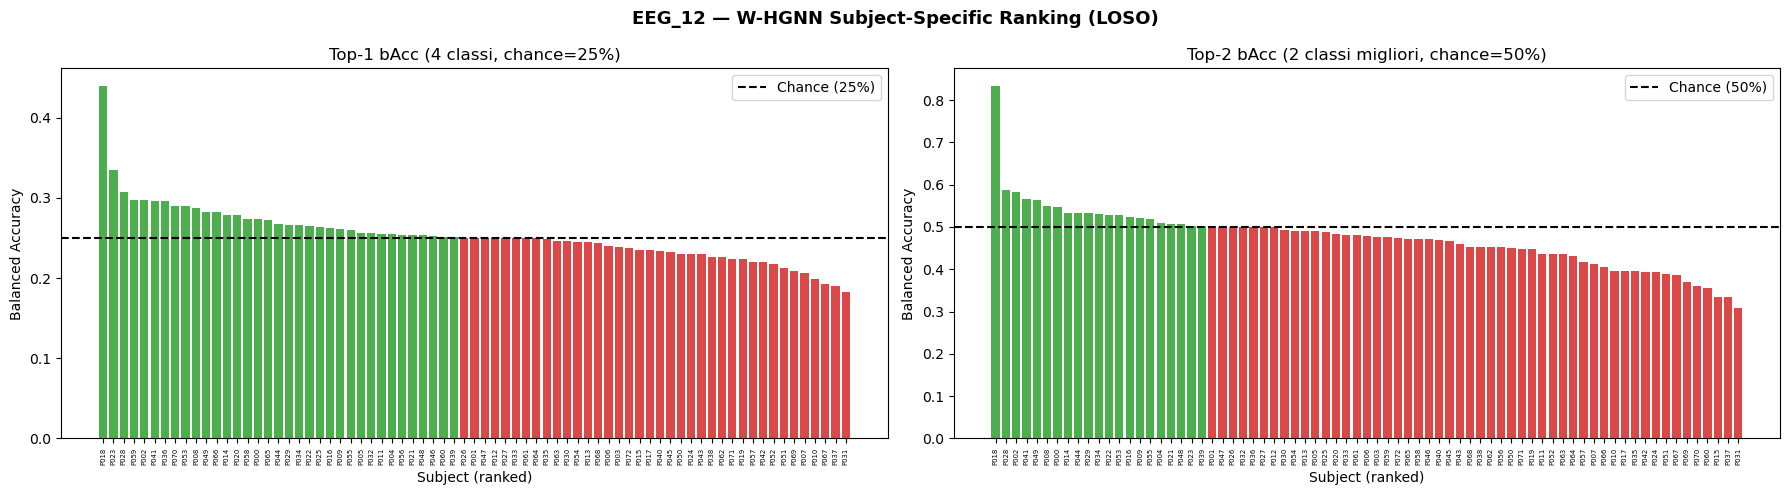

In [7]:
if 'df_top1' not in dir():
    print('[INFO] Esegui prima §6.')
else:
    chance = 1 / N_CLASSES
    chance2 = 0.5

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
    fig.suptitle('EEG_12 — W-HGNN Subject-Specific Ranking (LOSO)', fontsize=13, fontweight='bold')

    for ax, df, col, ch, title in [
        (ax1, df_top1, 'Test bAcc', chance,  f'Top-1 bAcc (4 classi, chance={chance:.0%})'),
        (ax2, df_top2, 'Top2 bAcc', chance2, f'Top-2 bAcc (2 classi migliori, chance={chance2:.0%})')
    ]:
        vals = df[col].values
        colors = ['#2ca02c' if v > ch else '#d62728' for v in vals]
        ax.bar(range(len(vals)), vals, color=colors, alpha=0.85, edgecolor='none')
        ax.axhline(ch, color='black', ls='--', lw=1.5, label=f'Chance ({ch:.0%})')
        ax.set_xticks(range(len(vals)))
        ax.set_xticklabels(df['Subject'], rotation=90, fontsize=5)
        ax.set_xlabel('Subject (ranked)'); ax.set_ylabel('Balanced Accuracy')
        ax.set_title(title); ax.legend()

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'eeg12_whgnn_ranking.png', dpi=150, bbox_inches='tight')
    plt.show()


## §8 — Confronto W-HGNN vs HGNN Statico (EEG_09b)

Top-10 confronto W-HGNN vs HGNN statico:
Subject  W-HGNN (EEG_12)  HGNN (EEG_09b)  Delta
   P018           0.4394          0.2500 0.1894
   P023           0.3347          0.1966 0.1381
   P028           0.3075          0.2287 0.0788
   P059           0.2975          0.2443 0.0532
   P002           0.2973          0.2443 0.0530
   P041           0.2966          0.2440 0.0526
   P036           0.2955          0.2605 0.0350
   P070           0.2901          0.2502 0.0399
   P053           0.2895          0.2244 0.0651
   P008           0.2871          0.2384 0.0487

Delta medio (W-HGNN - HGNN): 0.0038


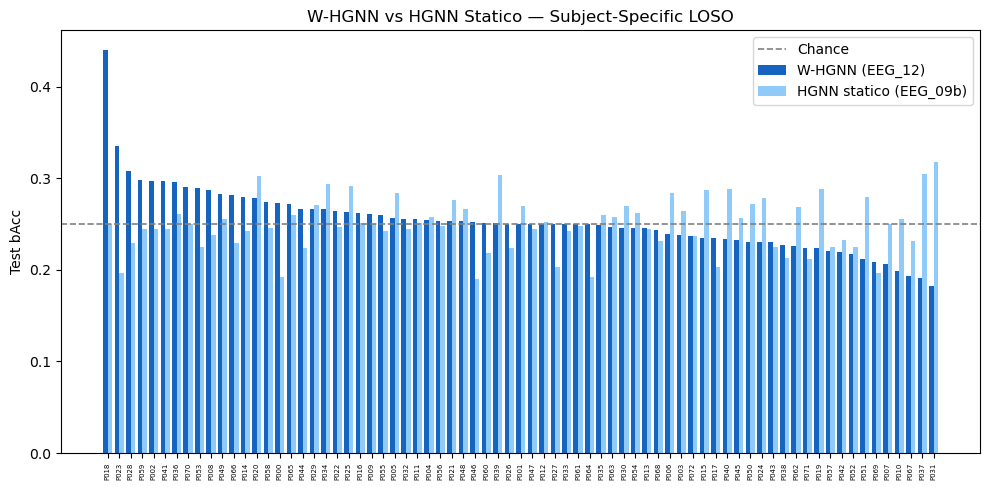

In [8]:
if 'df_top1' not in dir():
    print('[INFO] Esegui prima §6.')
else:
    # Carica ranking EEG_09b se disponibile
    csv09b = FIG_DIR / 'eeg09b_subject_ranking.csv'
    if csv09b.exists():
        df09b = pd.read_csv(csv09b)
        df_cmp = df_top1[['Subject', 'Test bAcc']].rename(columns={'Test bAcc': 'W-HGNN (EEG_12)'})
        df_cmp = df_cmp.merge(
            df09b[['Subject', 'Test bAcc']].rename(columns={'Test bAcc': 'HGNN (EEG_09b)'}),
            on='Subject', how='left'
        )
        df_cmp['Delta'] = df_cmp['W-HGNN (EEG_12)'] - df_cmp['HGNN (EEG_09b)']
        df_cmp = df_cmp.sort_values('W-HGNN (EEG_12)', ascending=False).reset_index(drop=True)

        print('Top-10 confronto W-HGNN vs HGNN statico:')
        print(df_cmp.head(10).to_string(index=False))
        print(f'\nDelta medio (W-HGNN - HGNN): {df_cmp["Delta"].mean():.4f}')

        fig, ax = plt.subplots(figsize=(10, 5))
        x = np.arange(len(df_cmp))
        ax.bar(x - 0.2, df_cmp['W-HGNN (EEG_12)'], 0.4, label='W-HGNN (EEG_12)', color='#1565C0')
        ax.bar(x + 0.2, df_cmp['HGNN (EEG_09b)'],  0.4, label='HGNN statico (EEG_09b)', color='#90CAF9')
        ax.axhline(1/N_CLASSES, color='gray', ls='--', lw=1.2, label='Chance')
        ax.set_xticks(x)
        ax.set_xticklabels(df_cmp['Subject'], rotation=90, fontsize=5)
        ax.set_ylabel('Test bAcc')
        ax.set_title('W-HGNN vs HGNN Statico — Subject-Specific LOSO')
        ax.legend()
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'eeg12_vs_09b.png', dpi=150, bbox_inches='tight')
        plt.show()
        df_cmp.to_csv(FIG_DIR / 'eeg12_vs_09b.csv', index=False)
    else:
        print('[INFO] eeg09b_subject_ranking.csv non trovato — esegui EEG_09b prima.')


## §9 — Confusion Matrix Top-5

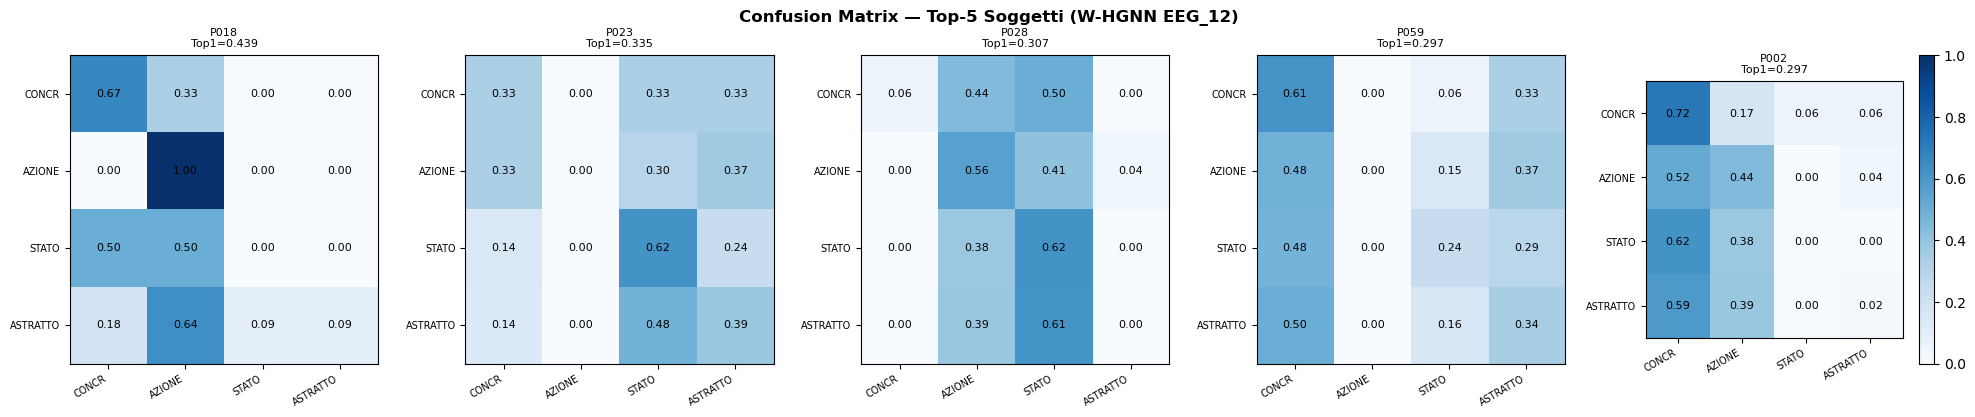

In [9]:
if 'df_top1' not in dir():
    print('[INFO] Esegui prima §6.')
else:
    from sklearn.metrics import confusion_matrix
    CLASS_NAMES = ['CONCR', 'AZIONE', 'STATO', 'ASTRATTO']

    top5 = df_top1.head(5)
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle('Confusion Matrix — Top-5 Soggetti (W-HGNN EEG_12)', fontsize=12, fontweight='bold')

    for ax, (_, row) in zip(axes, top5.iterrows()):
        sid = int(row['Subject'][1:])
        res = SUBJECT_RESULTS.get(sid)
        if res is None or 'labels' not in res:
            ax.set_title(row['Subject']); ax.axis('off'); continue
        lbl  = np.array(res['labels']); pred = np.array(res['preds'])
        cm   = confusion_matrix(lbl, pred, labels=list(range(N_CLASSES)), normalize='true')
        im   = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
        ax.set_xticks(range(N_CLASSES))
        ax.set_xticklabels(CLASS_NAMES, fontsize=7, rotation=30, ha='right')
        ax.set_yticks(range(N_CLASSES))
        ax.set_yticklabels(CLASS_NAMES, fontsize=7)
        for i in range(N_CLASSES):
            for j in range(N_CLASSES):
                ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center', fontsize=8)
        ax.set_title(f'{row["Subject"]}\nTop1={row["Test bAcc"]:.3f}', fontsize=8)

    plt.colorbar(im, ax=axes[-1])
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'eeg12_cm_top5.png', dpi=150, bbox_inches='tight')
    plt.show()
